# Day 10 — Inferential Statistics
### Hypothesis Testing · p-values · t-tests · Chi-Square Test

## 1. Setup & Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy

plt.style.use("dark_background")
sns.set_palette("husl")

df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")

print(f"NumPy:    {np.__version__}")
print(f"SciPy:    {scipy.__version__}")
print(f"Pandas:   {pd.__version__}")
print(f"Dataset:  {df.shape}")
print("Ready! ✅")

NumPy:    2.4.3
SciPy:    1.17.1
Pandas:   2.3.3
Dataset:  (891, 12)
Ready! ✅


## 2. What is Inferential Statistics?

In [ ]:
print("=" * 55)
print("   DESCRIPTIVE vs INFERENTIAL STATISTICS")
print("=" * 55)
print(
    """
DESCRIPTIVE (Day 8):
  - Summarises WHAT the data looks like
  - Mean, median, std dev, charts
  - "The average age was 29.7"

INFERENTIAL (Today):
  - Makes CONCLUSIONS beyond the data
  - Tests whether patterns are real or just chance
  - "Age SIGNIFICANTLY affected survival (p=0.039)"

KEY QUESTION Inferential Stats answers:
  "Is this pattern REAL, or did it happen by CHANCE?"

THE PROCESS:
  1. State H0 (Null Hypothesis)  — assume NO effect
  2. State H1 (Alternative)      — assume THERE IS effect
  3. Choose significance level   — usually alpha = 0.05
  4. Run the statistical test
  5. Get p-value
  6. If p < 0.05 → Reject H0 → Effect is REAL
     If p > 0.05 → Fail to reject H0 → Could be chance
"""
)

   DESCRIPTIVE vs INFERENTIAL STATISTICS

DESCRIPTIVE (Day 8):
  - Summarises WHAT the data looks like
  - Mean, median, std dev, charts
  - "The average age was 29.7"

INFERENTIAL (Today):
  - Makes CONCLUSIONS beyond the data
  - Tests whether patterns are real or just chance
  - "Age SIGNIFICANTLY affected survival (p=0.039)"

KEY QUESTION Inferential Stats answers:
  "Is this pattern REAL, or did it happen by CHANCE?"

THE PROCESS:
  1. State H0 (Null Hypothesis)  — assume NO effect
  2. State H1 (Alternative)      — assume THERE IS effect
  3. Choose significance level   — usually alpha = 0.05
  4. Run the statistical test
  5. Get p-value
  6. If p < 0.05 → Reject H0 → Effect is REAL
     If p > 0.05 → Fail to reject H0 → Could be chance



## 3. One-Sample t-test

In [ ]:
print("=" * 55)
print("        ONE-SAMPLE t-TEST")
print("=" * 55)
print(
    """
QUESTION: Was the average Titanic passenger age
          significantly different from 30?

H0: Mean age = 30 (no difference)
H1: Mean age ≠ 30 (there IS a difference)
"""
)

ages = df["Age"].dropna()
pop_mean = 30

t_stat, p_value = stats.ttest_1samp(ages, pop_mean)

print(f"Sample Mean:     {ages.mean():.4f}")
print(f"Hypothesised Mean: {pop_mean}")
print(f"Sample Size:     {len(ages)}")
print(f"t-statistic:     {t_stat:.4f}")
print(f"p-value:         {p_value:.4f}")
print()
if p_value < 0.05:
    print(f"Result: SIGNIFICANT ✅ (p={p_value:.4f} < 0.05)")
    print(f"The mean age IS significantly different from {pop_mean}")
else:
    print(f"Result: NOT significant ❌ (p={p_value:.4f} > 0.05)")
    print(f"The mean age is NOT significantly different from {pop_mean}")

        ONE-SAMPLE t-TEST

QUESTION: Was the average Titanic passenger age
          significantly different from 30?

H0: Mean age = 30 (no difference)
H1: Mean age ≠ 30 (there IS a difference)

Sample Mean:     29.6991
Hypothesised Mean: 30
Sample Size:     714
t-statistic:     -0.5535
p-value:         0.5801

Result: NOT significant ❌ (p=0.5801 > 0.05)
The mean age is NOT significantly different from 30


## 4. Two-Sample t-test

In [ ]:
print("=" * 55)
print("        TWO-SAMPLE t-TEST")
print("=" * 55)
print(
    """
QUESTION: Did survivors and non-survivors have
          significantly different ages?

H0: Mean age of survivors = Mean age of non-survivors
H1: Mean ages ARE different
"""
)

survived_ages = df[df["Survived"] == 1]["Age"].dropna()
died_ages = df[df["Survived"] == 0]["Age"].dropna()

t_stat, p_value = stats.ttest_ind(survived_ages, died_ages)

print(f"Survivors     — Mean Age: {survived_ages.mean():.2f} (n={len(survived_ages)})")
print(f"Non-survivors — Mean Age: {died_ages.mean():.2f} (n={len(died_ages)})")
print(
    f"Difference:               {abs(survived_ages.mean() - died_ages.mean()):.2f} years"
)
print()
print(f"t-statistic:  {t_stat:.4f}")
print(f"p-value:      {p_value:.4f}")
print()
if p_value < 0.05:
    print(f"Result: SIGNIFICANT ✅ (p={p_value:.4f} < 0.05)")
    print("Age DID significantly affect survival!")
else:
    print(f"Result: NOT significant ❌ (p={p_value:.4f} > 0.05)")
    print("No significant age difference between groups")

print()
print("=" * 55)
print("  FARE: Did survivors pay significantly more?")
print("=" * 55)

survived_fares = df[df["Survived"] == 1]["Fare"]
died_fares = df[df["Survived"] == 0]["Fare"]

t2, p2 = stats.ttest_ind(survived_fares, died_fares)
print(f"Survivors     — Mean Fare: £{survived_fares.mean():.2f}")
print(f"Non-survivors — Mean Fare: £{died_fares.mean():.2f}")
print(f"t-statistic:  {t2:.4f}")
print(f"p-value:      {p2:.6f}")
if p2 < 0.05:
    print(f"Result: SIGNIFICANT ✅ — Fare DID affect survival!")

        TWO-SAMPLE t-TEST

QUESTION: Did survivors and non-survivors have
          significantly different ages?

H0: Mean age of survivors = Mean age of non-survivors
H1: Mean ages ARE different

Survivors     — Mean Age: 28.34 (n=290)
Non-survivors — Mean Age: 30.63 (n=424)
Difference:               2.28 years

t-statistic:  -2.0667
p-value:      0.0391

Result: SIGNIFICANT ✅ (p=0.0391 < 0.05)
Age DID significantly affect survival!

  FARE: Did survivors pay significantly more?
Survivors     — Mean Fare: £48.40
Non-survivors — Mean Fare: £22.12
t-statistic:  7.9392
p-value:      0.000000
Result: SIGNIFICANT ✅ — Fare DID affect survival!


## 5. Chi-Square Test

In [ ]:
print("=" * 55)
print("         CHI-SQUARE TEST")
print("=" * 55)
print(
    """
QUESTION: Is there a significant relationship
          between Gender and Survival?

H0: Gender and Survival are INDEPENDENT (no relationship)
H1: Gender and Survival ARE related
"""
)

# Create contingency table
contingency = pd.crosstab(df["Sex"], df["Survived"])
contingency.columns = ["Died", "Survived"]
print("Contingency Table:")
print(contingency)
print()

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_value:.10f}")
print()
if p_value < 0.05:
    print(f"Result: SIGNIFICANT ✅ (p < 0.05)")
    print("Gender and Survival ARE significantly related!")
else:
    print(f"Result: NOT significant ❌")

print()
print("=" * 55)
print("  PCLASS vs SURVIVAL — Chi-Square")
print("=" * 55)

contingency2 = pd.crosstab(df["Pclass"], df["Survived"])
contingency2.columns = ["Died", "Survived"]
print("Contingency Table:")
print(contingency2)
print()

chi2_2, p2, dof2, _ = stats.chi2_contingency(contingency2)
print(f"Chi-square statistic: {chi2_2:.4f}")
print(f"Degrees of freedom:   {dof2}")
print(f"p-value:              {p2:.10f}")
if p2 < 0.05:
    print(f"Result: SIGNIFICANT ✅ — Class and Survival ARE related!")

         CHI-SQUARE TEST

QUESTION: Is there a significant relationship
          between Gender and Survival?

H0: Gender and Survival are INDEPENDENT (no relationship)
H1: Gender and Survival ARE related

Contingency Table:
        Died  Survived
Sex                   
female    81       233
male     468       109

Chi-square statistic: 260.7170
Degrees of freedom:   1
p-value:              0.0000000000

Result: SIGNIFICANT ✅ (p < 0.05)
Gender and Survival ARE significantly related!

  PCLASS vs SURVIVAL — Chi-Square
Contingency Table:
        Died  Survived
Pclass                
1         80       136
2         97        87
3        372       119

Chi-square statistic: 102.8890
Degrees of freedom:   2
p-value:              0.0000000000
Result: SIGNIFICANT ✅ — Class and Survival ARE related!


## 6. Visualising the Results

c:\DS-AI-75d\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\DS-AI-75d\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\vijen\AppData\Local\Temp\ipykernel_17608\4179984137.py:32: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\DS-AI-75d\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


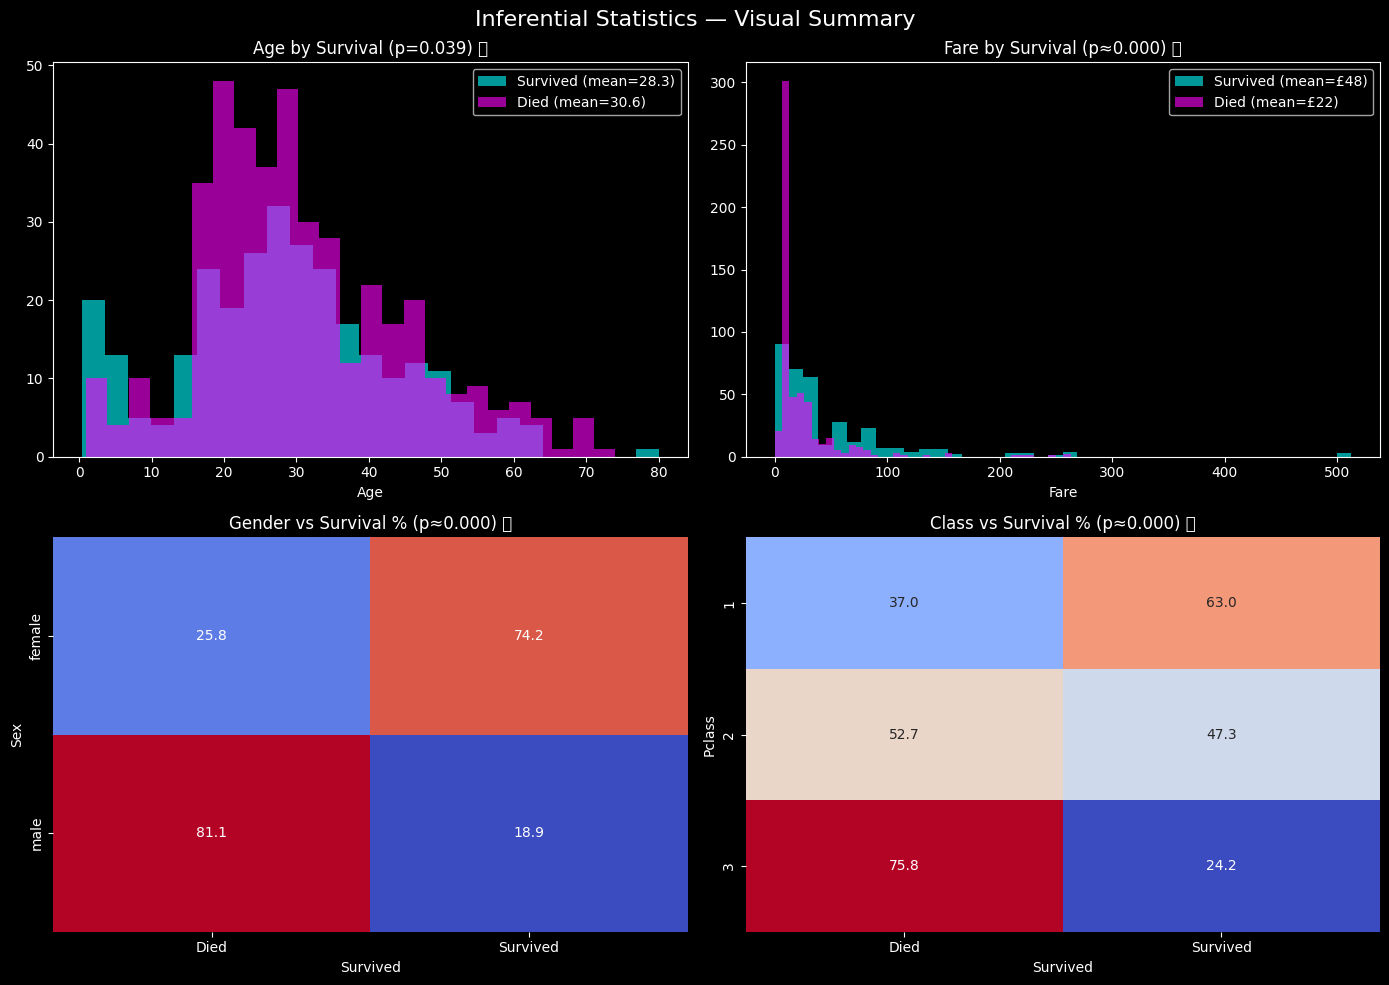

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Inferential Statistics — Visual Summary", fontsize=16)

# Plot 1 — Age by survival (two-sample t-test)
axes[0, 0].hist(
    survived_ages,
    bins=25,
    alpha=0.6,
    color="cyan",
    label=f"Survived (mean={survived_ages.mean():.1f})",
)
axes[0, 0].hist(
    died_ages,
    bins=25,
    alpha=0.6,
    color="magenta",
    label=f"Died (mean={died_ages.mean():.1f})",
)
axes[0, 0].set_title(f"Age by Survival (p=0.039) ✅")
axes[0, 0].set_xlabel("Age")
axes[0, 0].legend()

# Plot 2 — Fare by survival
axes[0, 1].hist(
    survived_fares,
    bins=40,
    alpha=0.6,
    color="cyan",
    label=f"Survived (mean=£{survived_fares.mean():.0f})",
)
axes[0, 1].hist(
    died_fares,
    bins=40,
    alpha=0.6,
    color="magenta",
    label=f"Died (mean=£{died_fares.mean():.0f})",
)
axes[0, 1].set_title(f"Fare by Survival (p≈0.000) ✅")
axes[0, 1].set_xlabel("Fare")
axes[0, 1].legend()

# Plot 3 — Gender contingency heatmap
gender_surv = pd.crosstab(df["Sex"], df["Survived"], normalize="index") * 100
sns.heatmap(
    gender_surv, annot=True, fmt=".1f", cmap="coolwarm", ax=axes[1, 0], cbar=False
)
axes[1, 0].set_title("Gender vs Survival % (p≈0.000) ✅")
axes[1, 0].set_xticklabels(["Died", "Survived"])

# Plot 4 — Class contingency heatmap
class_surv = pd.crosstab(df["Pclass"], df["Survived"], normalize="index") * 100
sns.heatmap(
    class_surv, annot=True, fmt=".1f", cmap="coolwarm", ax=axes[1, 1], cbar=False
)
axes[1, 1].set_title("Class vs Survival % (p≈0.000) ✅")
axes[1, 1].set_xticklabels(["Died", "Survived"])

plt.tight_layout()
plt.show()

## 7. Key Takeaways — Day 10 🎯

### Inferential vs Descriptive Statistics
- **Descriptive** — summarises what data looks like (mean, std, charts)
- **Inferential** — tests whether patterns are real or just chance
- Key question: "Is this pattern real, or did it happen by chance?"

### Hypothesis Testing Framework
- **H0 (Null Hypothesis)** — assume NO effect exists
- **H1 (Alternative)** — assume effect DOES exist
- **Alpha (α)** — significance threshold, usually 0.05
- **p-value** — probability the result happened by chance
- p < 0.05 → Reject H0 → Effect is real ✅
- p > 0.05 → Fail to reject H0 → Could be chance ❌

### One-Sample t-test
- Tests if a sample mean differs from a known value
- Age vs 30: p=0.58 → NOT significant (29.7 ≈ 30 statistically)

### Two-Sample t-test
- Compares means of TWO groups
- Age (survived vs died): p=0.039 → SIGNIFICANT ✅
- Fare (survived vs died): p≈0.000 → HIGHLY SIGNIFICANT ✅

### Chi-Square Test
- Tests relationship between TWO categorical variables
- Use when both variables are categories (not numbers)
- Gender vs Survival: p≈0.000 → HIGHLY SIGNIFICANT ✅
- Class vs Survival: p≈0.000 → HIGHLY SIGNIFICANT ✅

### When to Use Which Test
| Test | Use When | Example |
|---|---|---|
| One-sample t-test | Sample mean vs known value | Is avg age different from 30? |
| Two-sample t-test | Compare means of 2 groups | Do survivors differ in age? |
| Chi-square | Two categorical variables | Does gender affect survival? |

### Tools Used
- `stats.ttest_1samp(data, value)` — one sample t-test
- `stats.ttest_ind(group1, group2)` — two sample t-test
- `stats.chi2_contingency(table)` — chi-square test
- `pd.crosstab(col1, col2)` — contingency table